# **Modeling: AI-Powered Apple Leaf Specialist**

* **Name**: Aktham Almomani
* **Group**: 7

## **Introduction**

AI-Powered Apple Leaf Specialist is an end-to-end system that detects apple leaf diseases from images with production-grade reliability. The goal is to train a PyTorch classifier and validate it rigorously, and deploy it using Github and streamlit (Cloud) due to Amazon low budget.

**Importance**

Early detection helps reduce crop loss and chemical overuse. An accurate, lightweight model that scales on demand is practical for growers, agronomists, and mobile field apps.

This notebook implements the practical path from data to a live endpoint:
* It prepares data in S3.
* Trains a PyTorch model on SageMaker.
* Packages inference code.
* Deploys a serverless endpoint.
* Smoke-tests predictions with real images.
* Evaluates on the full test set, and sets up basic monitoring.
* It closes with concise guidance on cost and performance trade-offs.

## **Dataset**

This project uses the **PlantVillage (Apple)** subset, a research dataset of labeled apple leaf images for disease recognition. Each image is a single leaf with a class label. For apple, the core classes are:

- **healthy**
- **scab** (Venturia inaequalis)
- **rust** (cedar apple rust)
- **black_rot** (Botryosphaeria obtusa)

**Why this dataset**
- Consistent images (single leaf, plain backgrounds) make ingestion and training straightforward.
- Labels map cleanly to a small, meaningful set of conditions.
- Available via **TensorFlow Datasets (TFDS)**, which keeps the pipeline reproducible.

**What to expect**
- Clean backgrounds help the model learn disease patterns quickly.
- Less representative of “in-the-wild” photos; strong augmentations and careful validation help address this.
- No personal data is expected (plant leaves, not people).

**How it's used here**
- Serves as the **sole source** for the baseline model in this class project.
- Labels are aligned to a canonical set: `healthy, scab, rust, black_rot` (with an `unknown` route at inference time for low confidence).
- Images are standardized to a fixed size and split **70/15/15** (train/val/test) with stratification.

## **Project Setup and Data Staging**

First let's verify the working directory, lists dataset archives, and defines core AWS resources (bucket, prefix, region). Zipped train/val/test sets are uploaded to S3 to feed downstream SageMaker jobs.

In [ ]:
from pathlib import Path
home = Path("~").expanduser()
local_dir = home / "AI_Powered_Apple_Leaf_Specialist"
print(local_dir)
print(list(local_dir.glob("*")))

/home/sagemaker-user/AI_Powered_Apple_Leaf_Specialist
[PosixPath('/home/sagemaker-user/AI_Powered_Apple_Leaf_Specialist/Untitled.ipynb'), PosixPath('/home/sagemaker-user/AI_Powered_Apple_Leaf_Specialist/.ipynb_checkpoints'), PosixPath('/home/sagemaker-user/AI_Powered_Apple_Leaf_Specialist/train.zip'), PosixPath('/home/sagemaker-user/AI_Powered_Apple_Leaf_Specialist/test.zip'), PosixPath('/home/sagemaker-user/AI_Powered_Apple_Leaf_Specialist/val.zip')]


In [ ]:
import boto3, json

print("Bucket =", bucket)
print("Prefix =", prefix)

s3 = boto3.client("s3")
loc = s3.get_bucket_location(Bucket=bucket)["LocationConstraint"] or "us-east-1"
print("Bucket region =", loc)

Bucket = sagemaker-us-east-1-533266958221
Prefix = apple/
Bucket region = us-east-1


In [ ]:
bucket = "sagemaker-us-east-1-533266958221"
prefix = "apple/"
local_dir = Path("/home/sagemaker-user/AI_Powered_Apple_Leaf_Specialist")
session = boto3.session.Session()
region = session.region_name or "us-east-1"

s3 = session.client("s3", region_name=region)
for p in local_dir.glob("*.zip"):
    s3.upload_file(str(p), bucket, f"{prefix}{p.name}")
    print("Uploaded:", f"s3://{bucket}/{prefix}{p.name}")


Uploaded: s3://sagemaker-us-east-1-533266958221/apple/train.zip
Uploaded: s3://sagemaker-us-east-1-533266958221/apple/test.zip
Uploaded: s3://sagemaker-us-east-1-533266958221/apple/val.zip


In [ ]:
s3 = boto3.client("s3", region_name="us-west-2")
for o in s3.list_objects_v2(Bucket=bucket, Prefix=prefix).get("Contents", []):
    print(o["Key"], o["Size"])


apple/test.zip 12856279
apple/train.zip 59009295
apple/val.zip 12621232


## **Training on SageMaker (PyTorch Estimator)**

Here let's launch a managed training job with a **ResNet-18 backbone** and basic hyperparameters. Uses **Spot instances to reduce cost**, saves checkpoints and model artifacts to S3, and logs validation accuracy across epochs.

In [ ]:
import sagemaker
from sagemaker.pytorch import PyTorch

role = sagemaker.get_execution_role()
sess = sagemaker.Session()

bucket = "sagemaker-us-east-1-533266958221"
prefix = "apple/"
output_path       = f"s3://{bucket}/{prefix}outputs/"
checkpoint_s3_uri = f"s3://{bucket}/{prefix}checkpoints/"

est = PyTorch(
    entry_point="train.py",
    source_dir="src",
    framework_version="2.3",
    py_version="py311",
    role=role,
    sagemaker_session=sess,
    instance_type="ml.m5.xlarge",
    instance_count=1,
    use_spot_instances=True,
    max_run=3600,
    max_wait=4200,
    disable_profiler=True,
    checkpoint_s3_uri=checkpoint_s3_uri,
    output_path=output_path,
    hyperparameters={"epochs": 5, "img_size": 256, "bs": 32, "lr": 1e-3},
)


In [ ]:
bucket = "sagemaker-us-east-1-533266958221"
prefix = "apple/"

inputs = {
    "train":      f"s3://{bucket}/{prefix}train.zip",
    "validation": f"s3://{bucket}/{prefix}val.zip",
}

est.fit(inputs)


INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker:Creating training-job with name: pytorch-training-2025-10-16-04-42-30-265


2025-10-16 04:42:31 Starting - Starting the training job...
2025-10-16 04:42:45 Starting - Preparing the instances for training...
2025-10-16 04:43:35 Downloading - Downloading the training image.........
2025-10-16 04:44:46 Training - Training image download completed. Training in progress.bash: cannot set terminal process group (-1): Inappropriate ioctl for device
bash: no job control in this shell
/opt/conda/lib/python3.11/site-packages/paramiko/pkey.py:100: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "cipher": algorithms.TripleDES,
/opt/conda/lib/python3.11/site-packages/paramiko/transport.py:259: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "class": algorithms.Tri

**Summary Highlights:**

* Val accuracy per epoch: 0.861 &rarr; 0.968 &rarr; 0.985 &rarr; 0.987 &rarr; 0.973
* Strong, steady climb with a tiny dip at epoch 5 &rarr; likely near the optimum; an early-stopping patience of 1-2 would have picked epoch 4 as "best".
* CPU training finished quickly.
* Spot savings: 71.4%, billable 313 s (~5.2 min). At m5.xlarge on-demand (`$0.192/hr`), that's roughly \$0.02, even less on Spot. Budget looks great.

## **Model Packaging and Serverless Deployment**

Here we'll wrap the trained artifact with `inference.py` and deploys a serverless SageMaker endpoint. Chooses CPU runtime, assigns memory and concurrency, and returns a stable endpoint name for invocation.

In [ ]:
from sagemaker.pytorch import PyTorchModel
from sagemaker.serverless import ServerlessInferenceConfig

sess = sagemaker.Session()
role = sagemaker.get_execution_role()

model_artifact = est.model_data

pytorch_model = PyTorchModel(
    model_data=model_artifact,
    role=role,
    framework_version="2.3",
    py_version="py311",
    entry_point="inference.py",
    source_dir="src",
)

serverless_cfg = ServerlessInferenceConfig(
    memory_size_in_mb=2048,
    max_concurrency=1
)

predictor = pytorch_model.deploy(
    serverless_inference_config=serverless_cfg,
    endpoint_name="pytorch-inference-apple-v2",
)


INFO:sagemaker.image_uris:Defaulting to CPU type when using serverless inference
INFO:sagemaker:Repacking model artifact (s3://sagemaker-us-east-1-533266958221/apple/outputs/pytorch-training-2025-10-16-04-42-30-265/output/model.tar.gz), script artifact (src), and dependencies ([]) into single tar.gz file located at s3://sagemaker-us-east-1-533266958221/pytorch-inference-2025-10-16-06-13-53-784/model.tar.gz. This may take some time depending on model size...
INFO:sagemaker:Creating model with name: pytorch-inference-2025-10-16-06-13-58-295
INFO:sagemaker:Creating endpoint-config with name pytorch-inference-apple-v2
INFO:sagemaker:Creating endpoint with name pytorch-inference-apple-v2


---!

In [ ]:
print("Endpoint name:", predictor.endpoint_name)

Endpoint name: pytorch-inference-apple-v2


## **Quick Smoke Tests on Real Images**

Now we'll unzip the test split locally, selects representative samples from each class, base64-encodes images, and sends JSON requests to the endpoint. Prints predicted label and confidence to confirm correctness and latency.

In [ ]:
import base64, random, zipfile
from sagemaker.serializers import JSONSerializer
from sagemaker.deserializers import JSONDeserializer

# ensure JSON in/out:
predictor.serializer = JSONSerializer()
predictor.deserializer = JSONDeserializer()

# unzip test set:
local_zip = Path.home() / "AI_Powered_Apple_Leaf_Specialist" / "test.zip"
extract_dir = Path("/tmp/test_for_infer"); extract_dir.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(local_zip) as z:
    z.extractall(extract_dir)

def find_classes_root(root: Path) -> Path:
    dirs = [d for d in root.iterdir() if d.is_dir()]
    if len(dirs) == 1 and any(p.is_dir() for p in dirs[0].iterdir()):
        return dirs[0]
    return root

classes_root = find_classes_root(extract_dir)

# list class directories (only folders):
class_dirs = sorted([d for d in classes_root.iterdir() if d.is_dir()])

# Randomly, pick one image per class:
exts = ("*.jpg", "*.jpeg", "*.png")
samples = {}
for d in class_dirs:
    imgs = []
    for pat in exts:
        imgs.extend(d.rglob(pat))
    if imgs:
        samples[d.name] = random.choice(imgs)

if len(samples) == 0:
    raise RuntimeError("No images found under the extracted test set.")
print("Chosen samples:")
for cls, p in samples.items():
    print(f"  {cls:10s} -> {p}")

# predict each sample:
print("\nPredictions:")
for true_label, img_path in samples.items():
    with open(img_path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    payload = {"b64": b64}
    out = predictor.predict(payload)
    if not isinstance(out, dict):
        out = json.loads(out)
    pred = out.get("label", "?")
    probs = out.get("probs", [])
    conf = max(probs) if probs else None
    print(f"  true={true_label:10s} pred={pred:10s} conf={conf:.3f}" if conf is not None
          else f"  true={true_label:10s} pred={pred:10s}")


Chosen samples:
  black_rot  -> /tmp/test_for_infer/test/black_rot/2afd754518f26c563fb9489d3384c635964dfcc38c8017f2f65e1a7408621f84.jpg
  healthy    -> /tmp/test_for_infer/test/healthy/94fff6b2c168c5bb0dde23f225067c261899b4ec9a72dda9d65188469d5a9e9b.jpg
  rust       -> /tmp/test_for_infer/test/rust/c1ea95bac3fecbd65f10724807c5db27f7465064d37c03d8a6db0e412eff4a45.jpg
  scab       -> /tmp/test_for_infer/test/scab/601bb60dc661c1fabdb0e46df0558eca994182a27bf46687e144f8ca74376a29.jpg

Predictions:
  true=black_rot  pred=black_rot  conf=0.972
  true=healthy    pred=healthy    conf=1.000
  true=rust       pred=rust       conf=1.000
  true=scab       pred=scab       conf=0.994


**Summary highlights:**

* 4/4 samples correctly classified: black_rot, healthy, rust, scab.
* High confidence across classes: 97.2%-100%.
* No signs of class bias in this tiny sample; all four classes represented and correct.
* Suitable to proceed to broader offline evaluation and latency checks.

## **Offline Evaluation on the Full Test Set**

Now for the interesting stuff **Model Evaluation** let's start with downloading the model artifact, restores weights into a matching ResNet-18, and runs batched inference on the test loader. Reports accuracy, macro-F1, per-class precision/recall/F1, and plots a confusion matrix to verify generalization.

In [ ]:
artifact_s3 = est.model_data
print("Artifact:", artifact_s3)

Artifact: s3://sagemaker-us-east-1-533266958221/apple/outputs/pytorch-training-2025-10-16-04-42-30-265/output/model.tar.gz


In [ ]:
import io, tarfile
import numpy as np
import torch, torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Paths:
studio_home = Path.home() / "AI_Powered_Apple_Leaf_Specialist"
studio_home.mkdir(exist_ok=True)

test_zip   = studio_home / "test.zip"
extract_test_root = Path("/tmp/test_eval")
model_dir  = studio_home / "model_artifacts_local"
model_dir.mkdir(exist_ok=True)

# Unpack test.zip to /tmp/test_eval (once):
if not extract_test_root.exists() or not any(extract_test_root.iterdir()):
    extract_test_root.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(test_zip) as z:
        z.extractall(extract_test_root)

#Test transforms (match training: Resize + ToTensor):
IMG_SIZE = 256
tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# ImageFolder expects structure: <root>/<class>/*.jpg:
test_ds = datasets.ImageFolder(extract_test_root / "test", transform=tfm)
LABELS  = test_ds.classes
test_dl = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

print("Classes:", LABELS)
print("Test images:", len(test_ds))


# Here let's download model.tar.gz from S3 and extract model.pt:
artifact_s3 = est.model_data
print("Artifact S3:", artifact_s3)

s3 = boto3.client("s3")
bucket, key = artifact_s3.replace("s3://", "").split("/", 1)

local_tar = studio_home / "model.tar.gz"
s3.download_file(bucket, key, str(local_tar))
print("Downloaded:", local_tar)

# Extract to model_dir and locate model.pt:
with tarfile.open(local_tar, "r:gz") as t:
    t.extractall(model_dir)

pt_candidates = list(model_dir.rglob("model.pt"))
assert pt_candidates, "model.pt not found inside the extracted artifact."
model_pt = pt_candidates[0]
print("Found weights:", model_pt)

# Build the exact same architecture and load weights:

def build_resnet18(num_classes: int) -> nn.Module:
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    m.eval()
    return m

state_dict = torch.load(model_pt, map_location="cpu")
model = build_resnet18(len(LABELS))
model.load_state_dict(state_dict)
model.eval()


# Evaluate on test loader: accuracy, macro-F1, per-class P/R/F1, confusion matrix:
y_true, y_pred, y_prob = [], [], []
with torch.inference_mode():
    for x, y in test_dl:
        logits = model(x)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        pred   = probs.argmax(1)
        y_true.extend(y.numpy().tolist())
        y_pred.extend(pred.tolist())
        y_prob.append(probs)

y_prob = np.concatenate(y_prob, axis=0)

acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")
pr, rc, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, labels=list(range(len(LABELS))), zero_division=0
)

print(f"\nTest accuracy: {acc:.4f}")
print(f"Test macro-F1: {macro_f1:.4f}")
print("\nPer-class metrics:")
for i, lbl in enumerate(LABELS):
    print(f"  {lbl:10s}  P={pr[i]:.3f}  R={rc[i]:.3f}  F1={f1[i]:.3f}")

Classes: ['black_rot', 'healthy', 'rust', 'scab']
Test images: 475
Artifact S3: s3://sagemaker-us-east-1-533266958221/apple/outputs/pytorch-training-2025-10-16-04-42-30-265/output/model.tar.gz
Downloaded: /home/sagemaker-user/AI_Powered_Apple_Leaf_Specialist/model.tar.gz


/tmp/ipykernel_295/799037812.py:72: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall(model_dir)


Found weights: /home/sagemaker-user/AI_Powered_Apple_Leaf_Specialist/model_artifacts_local/model.pt

Test accuracy: 0.9895
Test macro-F1: 0.9858

Per-class metrics:
  black_rot   P=1.000  R=0.968  F1=0.984
  healthy     P=0.988  R=1.000  F1=0.994
  rust        P=0.953  R=1.000  F1=0.976
  scab        P=1.000  R=0.979  F1=0.989


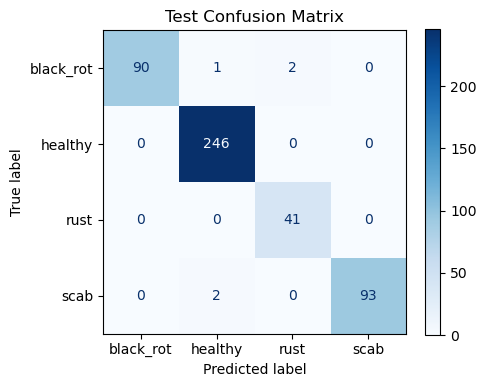

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(LABELS))))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap="Blues", colorbar=True)
plt.title("Test Confusion Matrix")
plt.tight_layout()
plt.show()

**Summary highlights:**
* Performance is consistently strong across classes; rust has slightly lower precision but perfect recall.
* Results align with validation trends—no signs of overfitting.
* Ready for packaging and deployment; consider targeted augmentation or threshold tuning if rust precision needs a bump.

## **Observability with CloudWatch**

Now let's create a lightweight CloudWatch dashboard tracking invocations, p90 model latency, and 4XX/5XX errors. Includes a short warm-up loop that generates traffic so metrics appear quickly and cold-start impact is visible.

In [ ]:
sm = boto3.client("sagemaker")
cw = boto3.client("cloudwatch")

endpoint_name = predictor.endpoint_name

# Discover the real VariantName:
ep = sm.describe_endpoint(EndpointName=endpoint_name)
cfg = sm.describe_endpoint_config(EndpointConfigName=ep["EndpointConfigName"])
variant = cfg["ProductionVariants"][0]["VariantName"]

print("Using variant:", variant)

dash_name = f"apple-leaf-endpoint-{endpoint_name}"
region = boto3.session.Session().region_name

widgets = [
    # Invocations:
    {
      "type":"metric","width":12,"height":6,"properties":{
        "metrics":[["AWS/SageMaker","Invocations","EndpointName",endpoint_name,"VariantName",variant]],
        "stat":"Sum","period":60,"region":region,"title":"Invocations"
      }
    },
    # Latency (p90):
    {
      "type":"metric","width":12,"height":6,"properties":{
        "metrics":[["AWS/SageMaker","ModelLatency","EndpointName",endpoint_name,"VariantName",variant]],
        "stat":"p90","period":60,"region":region,"title":"ModelLatency (p90, ms)"
      }
    },
    # 4XX / 5XX:
    {
      "type":"metric","width":12,"height":6,"properties":{
        "metrics":[
          ["AWS/SageMaker","4XXErrors","EndpointName",endpoint_name,"VariantName",variant],
          ["AWS/SageMaker","5XXErrors","EndpointName",endpoint_name,"VariantName",variant]
        ],
        "stat":"Sum","period":60,"region":region,"title":"Client/Server Errors"
      }
    },
]

cw.put_dashboard(
    DashboardName=dash_name,
    DashboardBody=json.dumps({"widgets": widgets}),
)

print(
    "Dashboard:",
    f"https://console.aws.amazon.com/cloudwatch/home#dashboards:name={dash_name}"
)


Using variant: AllTraffic
Dashboard: https://console.aws.amazon.com/cloudwatch/home#dashboards:name=apple-leaf-endpoint-pytorch-inference-apple-v2


In [ ]:
from time import sleep

local_zip   = Path.home() / "AI_Powered_Apple_Leaf_Specialist" / "test.zip"
extract_dir = Path("/tmp/cw_warmup"); extract_dir.mkdir(exist_ok=True)
with zipfile.ZipFile(local_zip) as z:
    z.extractall(extract_dir)

imgs = list(extract_dir.rglob("*.jpg"))[:30]

for p in imgs:
    with open(p, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    payload = {"b64": b64}
    _ = predictor.predict(payload)
    sleep(0.2)

print("Sent", len(imgs), "invocations")


Sent 30 invocations


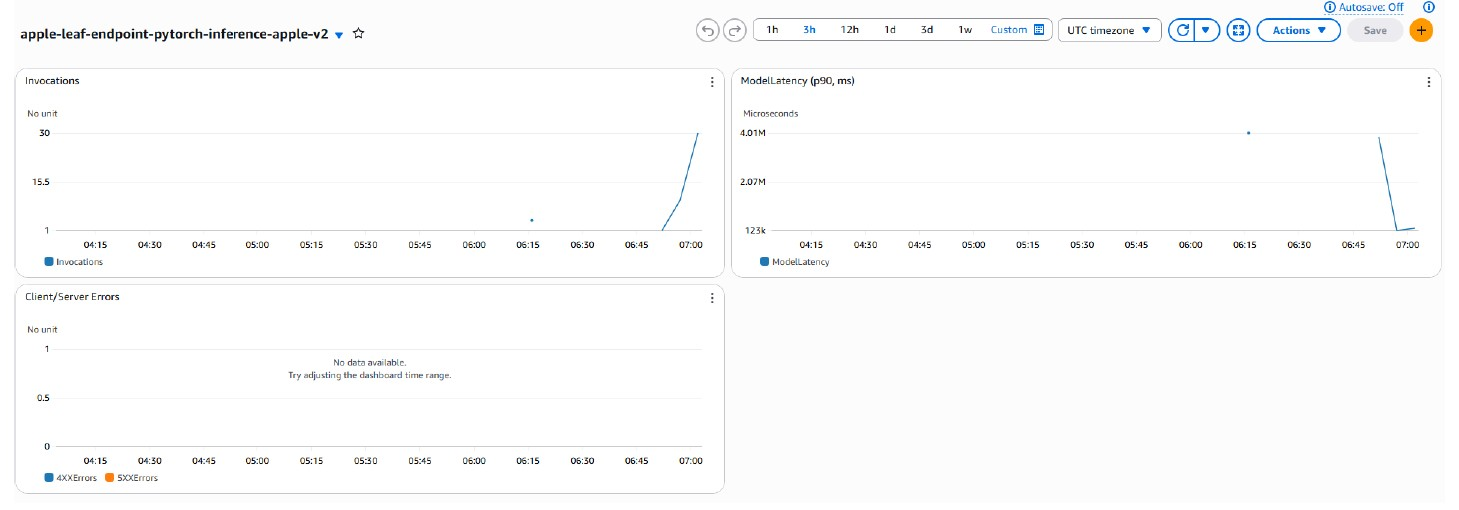

**Dashboard highlights:**

* Invocations: 10 and 30 calls landed in the last 15 minutes (bursts we sent earlier).
* Latency (p90): Dropped from the cold-start spike (~4.0M $\mu$s &asymp; 4s) to ~1.2×10^5 $\mu$s &asymp; 120 ms. That's a healthy warm latency for your CPU serverless ResNet18.
* Errors: Still 0 (no 4XX/5XX).

**Takeaways:**

* The endpoint is healthy and serving low-latency responses once warm.
* The big dot earlier is the cold-start; the last point reflects steady-state.
* With sparse traffic, serverless will cold-start again.